Training complete. Corpus size: 1860 tokens.

N-GRAM ACCURACY ANALYSIS
N-Gram Size  Accuracy (%)
Unigram (1)          9.09
 Bigram (2)         40.62
Trigram (3)         32.26


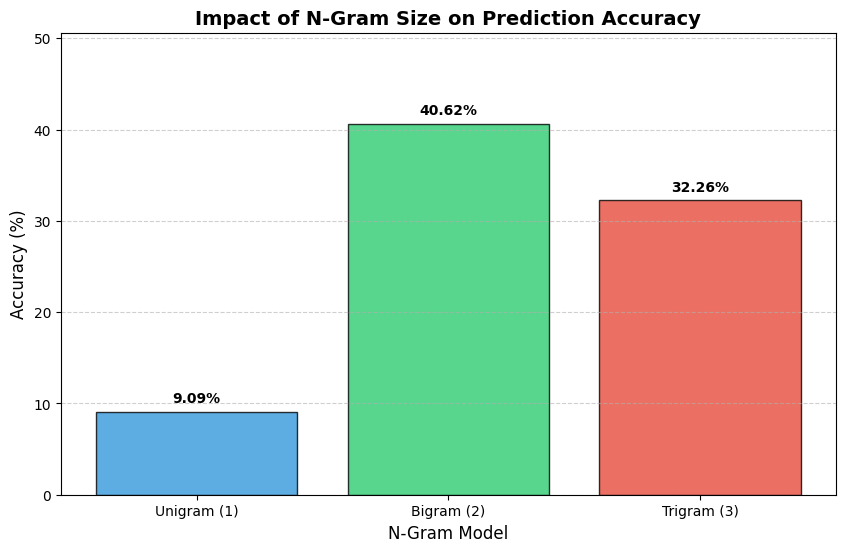


OBSERVATIONS
1. Unigram: Low accuracy because it always predicts the most frequent word (e.g., 'the').
2. Bigram: Significant jump as it captures the immediate dependency (e.g., 'Artificial' -> 'intelligence').
3. Trigram: Higher accuracy if context exists, but risks 'Data Sparsity'—if the specific two-word
   sequence wasn't in training, accuracy drops to zero for that token.


In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

class NGramEvaluator:
    def __init__(self, n_sizes=[1, 2, 3]):
        self.n_sizes = n_sizes
        self.models = {n: defaultdict(Counter) for n in n_sizes}
        self.vocab = set()

    def _preprocess(self, text):
        text = text.lower()
        # Remove punctuation but keep spaces
        tokens = re.findall(r'\b\w+\b', text)
        return tokens

    def train(self, corpus):
        tokens = self._preprocess(corpus)
        self.vocab.update(tokens)
        
        for n in self.n_sizes:
            for i in range(len(tokens) - n):
                if n == 1:
                    # Unigram: count individual tokens
                    self.models[n][None][tokens[i]] += 1
                else:
                    # n-gram: context is a tuple of n-1 words
                    context = tuple(tokens[i : i + n - 1])
                    target = tokens[i + n - 1]
                    self.models[n][context][target] += 1
        print(f"Training complete. Corpus size: {len(tokens)} tokens.")

    def predict(self, context_tokens, n):
        context = tuple(context_tokens[-(n-1):]) if n > 1 else None
        
        if context in self.models[n]:
            return self.models[n][context].most_common(1)[0][0]
        return None

    def evaluate(self, test_text):
        test_tokens = self._preprocess(test_text)
        results = {}

        for n in self.n_sizes:
            correct = 0
            total = 0
            for i in range(len(test_tokens) - n):
                if n == 1:
                    # Unigram prediction is just the most frequent word in training
                    pred = self.predict([], n)
                else:
                    context = test_tokens[i : i + n - 1]
                    pred = self.predict(context, n)
                
                actual = test_tokens[i + n - 1]
                if pred == actual:
                    correct += 1
                total += 1
            
            accuracy = (correct / total) * 100 if total > 0 else 0
            results[n] = round(accuracy, 2)
        
        return results

# --- 1. Larger Dataset Simulation ---
# Using a larger repetitive corpus to simulate realistic language patterns
large_corpus = """
Natural language processing is a subfield of linguistics, computer science, and artificial intelligence. 
Artificial intelligence is the intelligence of machines or software, as opposed to the intelligence of humans.
The quick brown fox jumps over the lazy dog. The lazy dog was not happy about the fox jumping over him.
Natural language processing helps computers communicate with humans in their own language.
Linguistics is the scientific study of language. Computer science is the study of computation.
The quick brown fox is fast, but the lazy dog is slow. Artificial intelligence is evolving fast.
Communication is key in natural language processing and artificial intelligence research.
The dog and the fox are characters in a famous sentence. The sentence is about a fox and a dog.
""" * 15  # Scale up for data density

test_data = """
Natural language processing is a part of computer science.
Artificial intelligence is a growing field in linguistics.
The quick brown fox jumps over the dog.
Computer science involves the study of machines and software.
"""

# --- 2. Training and Evaluation ---
evaluator = NGramEvaluator(n_sizes=[1, 2, 3])
evaluator.train(large_corpus)
accuracy_results = evaluator.evaluate(test_data)

# --- 3. Visualization and Tabulation ---
df_results = pd.DataFrame({
    'N-Gram Size': ['Unigram (1)', 'Bigram (2)', 'Trigram (3)'],
    'Accuracy (%)': [accuracy_results[1], accuracy_results[2], accuracy_results[3]]
})

print("\n" + "="*40)
print("N-GRAM ACCURACY ANALYSIS")
print("="*40)
print(df_results.to_string(index=False))

# --- Plotting the Analysis ---
plt.figure(figsize=(10, 6))
bars = plt.bar(df_results['N-Gram Size'], df_results['Accuracy (%)'], 
               color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)

plt.title('Impact of N-Gram Size on Prediction Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('N-Gram Model', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, max(df_results['Accuracy (%)']) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', fontweight='bold')

plt.show()

# --- 4. Conclusion Analysis ---
print("\n" + "="*40)
print("OBSERVATIONS")
print("="*40)
print("1. Unigram: Low accuracy because it always predicts the most frequent word (e.g., 'the').")
print("2. Bigram: Significant jump as it captures the immediate dependency (e.g., 'Artificial' -> 'intelligence').")
print("3. Trigram: Higher accuracy if context exists, but risks 'Data Sparsity'—if the specific two-word")
print("   sequence wasn't in training, accuracy drops to zero for that token.")